In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Ignore warnings
warnings.filterwarnings('ignore')

# Preprocessing and Model Selection
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Classical Machine Learning Models
from sklearn.linear_model import Perceptron  # Used for simple linear classification tasks.

# Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Deep Learning (TensorFlow / Keras)
from tensorflow.keras.models import Sequential  # Sequential lets you build a neural network layer-by-layer in Keras.
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, Dropout
from tensorflow.keras.utils import to_categorical

# Explanations for Keras Layers:
# - Dense makes the final predictions
# - Conv2D extracts features
# - Flatten reshapes them
# - MaxPooling2D reduces size
# - Dropout prevents overfitting
# - to_categorical numeric class label into one hot encoding fromat

In [10]:
train_df = pd.read_csv('train.csv')

In [11]:
train_df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
train_df.shape

(16636, 785)

In [13]:
train_df.columns

Index(['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5',
       'pixel6', 'pixel7', 'pixel8',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='object', length=785)

In [14]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16636 entries, 0 to 16635
Columns: 785 entries, label to pixel783
dtypes: float64(555), int64(230)
memory usage: 99.6 MB


In [15]:
train_df.isnull().sum()

,0
label,0
pixel0,0
pixel1,0
pixel2,0
pixel3,0
...,...
pixel779,1
pixel780,1
pixel781,1
pixel782,1


In [16]:
print(train_df.isnull().any(axis=1).sum())

1


In [17]:
train_df = train_df.dropna()

In [18]:
train_df.isnull().sum()

,0
label,0
pixel0,0
pixel1,0
pixel2,0
pixel3,0
...,...
pixel779,0
pixel780,0
pixel781,0
pixel782,0


In [19]:
X = train_df.drop('label', axis=1).values
y = train_df['label'].values

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
X_train = X_train.reshape(-1, 28, 28).astype('float32') / 255.0
X_test = X_test.reshape(-1, 28, 28).astype('float32') / 255.0

In [22]:
X_train

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [23]:
print(X_train.shape)

(13308, 28, 28)


In [24]:
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

In [25]:
Perceptron = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10, activation='softmax')
])

In [26]:
Perceptron.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

In [27]:
history_percep = Perceptron.fit(X_train, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test, y_test_cat),verbose=1)

Epoch 1/5
416/416 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6784 - loss: 1.3414 - val_accuracy: 0.8263 - val_loss: 0.8638
Epoch 2/5
416/416 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8372 - loss: 0.7463 - val_accuracy: 0.8512 - val_loss: 0.6408
Epoch 3/5
416/416 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8554 - loss: 0.6059 - val_accuracy: 0.8662 - val_loss: 0.5529
Epoch 4/5
416/416 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8671 - loss: 0.5388 - val_accuracy: 0.8735 - val_loss: 0.5047
Epoch 5/5
416/416 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8723 - loss: 0.4974 - val_accuracy: 0.8810 - val_loss: 0.4722


In [28]:
acc_percep = Perceptron.evaluate(X_test, y_test_cat)[1]
print(f'Accuracy: {acc_percep * 100:.2f}%')

104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8810 - loss: 0.4722
Accuracy: 88.10%


In [29]:
# ANN

ann = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

In [30]:
ann.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [31]:
history_ann = ann.fit(X_train, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test, y_test_cat),verbose=1)

Epoch 1/5
416/416 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8674 - loss: 0.4569 - val_accuracy: 0.9345 - val_loss: 0.2328
Epoch 2/5
416/416 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9439 - loss: 0.1868 - val_accuracy: 0.9480 - val_loss: 0.1663
Epoch 3/5
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9627 - loss: 0.1264 - val_accuracy: 0.9558 - val_loss: 0.1449
Epoch 4/5
416/416 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9732 - loss: 0.0889 - val_accuracy: 0.9630 - val_loss: 0.1250
Epoch 5/5
416/416 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9806 - loss: 0.0673 - val_accuracy: 0.9597 - val_loss: 0.1305


In [32]:
acc_ann = ann.evaluate(X_test, y_test_cat)[1]
print(f'Accuracy: {acc_ann * 100:.2f}%')

104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9597 - loss: 0.1305
Accuracy: 95.97%


In [33]:
X_train = X_train.reshape(-1, 28, 28,1)
X_test = X_test.reshape(-1, 28, 28,1)

In [37]:
cnn = Sequential([
    Conv2D(32, kernel_size=(3,3), activation ="relu", input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, kernel_size=(3,3), activation="relu"),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

In [38]:
cnn.compile(optimizer='adam', loss = "categorical_crossentropy", metrics=['accuracy'])

In [39]:
history_cnn = cnn.fit(X_train, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test, y_test_cat),verbose=1)

Epoch 1/5
416/416 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.8442 - loss: 0.4824 - val_accuracy: 0.9660 - val_loss: 0.1149
Epoch 2/5
416/416 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.9467 - loss: 0.1739 - val_accuracy: 0.9778 - val_loss: 0.0709
Epoch 3/5
416/416 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.9633 - loss: 0.1248 - val_accuracy: 0.9793 - val_loss: 0.0622
Epoch 4/5
416/416 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.9684 - loss: 0.1022 - val_accuracy: 0.9805 - val_loss: 0.0612
Epoch 5/5
416/416 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.9741 - loss: 0.0834 - val_accuracy: 0.9835 - val_loss: 0.0545


In [40]:
acc_cnn = cnn.evaluate(X_test, y_test_cat)[1]
print(f'Accuracy: {acc_cnn * 100:.2f}%')

104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9835 - loss: 0.0545
Accuracy: 98.35%


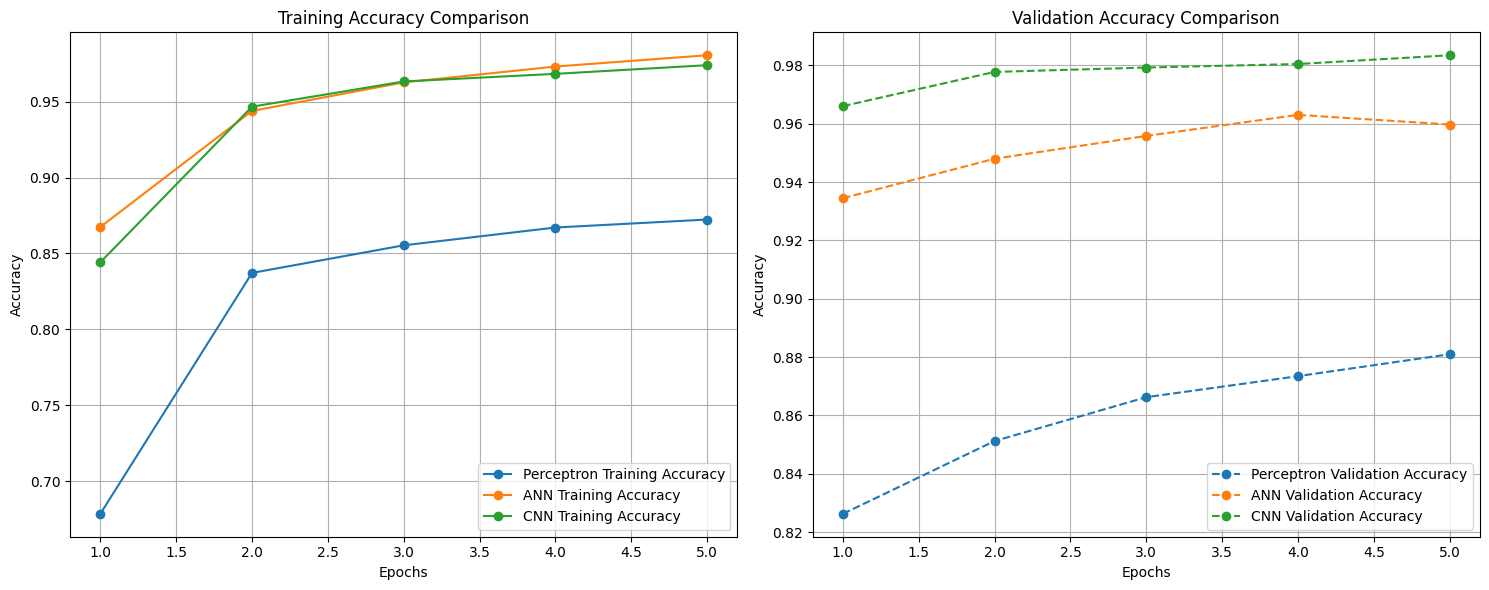

In [41]:
import matplotlib.pyplot as plt

# Get accuracy and loss from history objects
acc_percep = history_percep.history['accuracy']
val_acc_percep = history_percep.history['val_accuracy']

acc_ann = history_ann.history['accuracy']
val_acc_ann = history_ann.history['val_accuracy']

acc_cnn = history_cnn.history['accuracy']
val_acc_cnn = history_cnn.history['val_accuracy']

epochs = range(1, len(acc_percep) + 1)

plt.figure(figsize=(15, 6))

# Plot Training Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, acc_percep, 'o-', label='Perceptron Training Accuracy')
plt.plot(epochs, acc_ann, 'o-', label='ANN Training Accuracy')
plt.plot(epochs, acc_cnn, 'o-', label='CNN Training Accuracy')
plt.title('Training Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, val_acc_percep, 'o--', label='Perceptron Validation Accuracy')
plt.plot(epochs, val_acc_ann, 'o--', label='ANN Validation Accuracy')
plt.plot(epochs, val_acc_cnn, 'o--', label='CNN Validation Accuracy')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [46]:
def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs):
        plt.subplot(2, n, i+1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true[idx]}")
        preds = [np.argmax(model.predict(X_cnn[idx].reshape(1, 28, 28, 1) if name == "CNN" else X[idx].reshape(1, 28, 28)))
                 for model, name in zip(models, model_names)]
        plt.subplot(2, n, n+i+1)
        plt.axis("off")
        plt.title("\n".join(f"{n}: {p}" for n, p in zip(model_names, preds)))
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


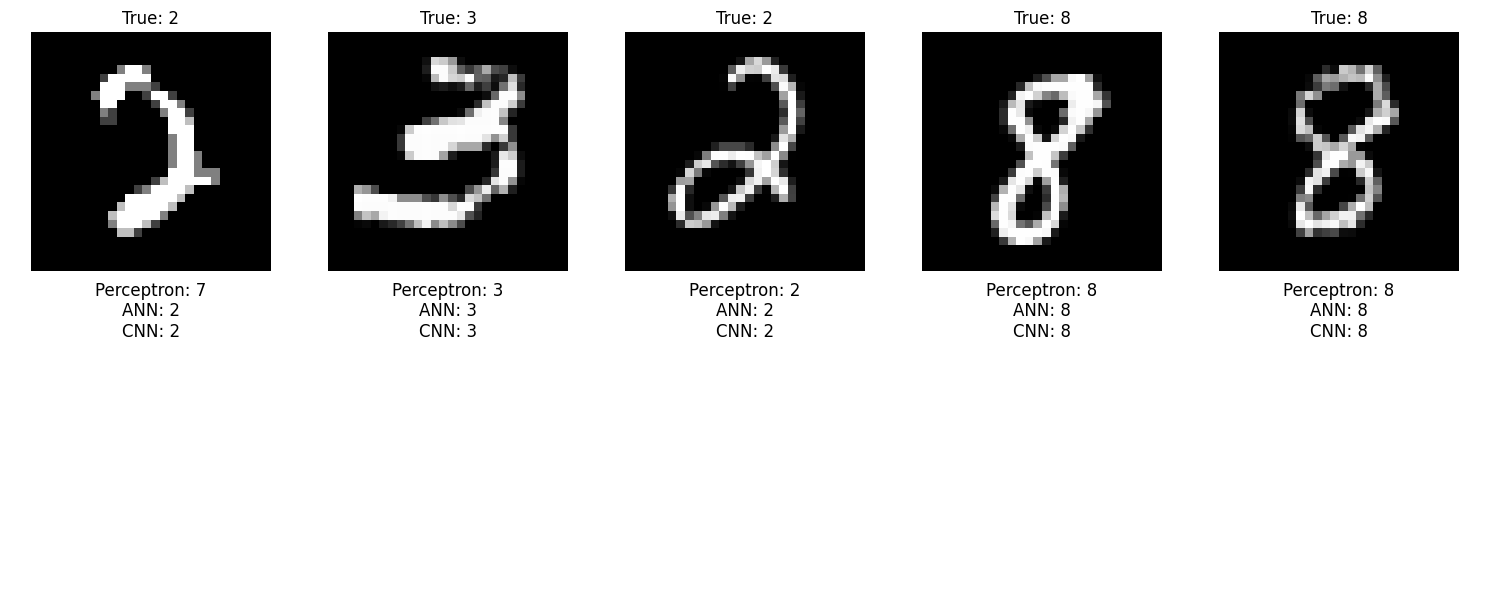

In [51]:
# X_test is currently in (num_samples, 28, 28, 1) format after the CNN setup.
# We need a 3D version for display and for models expecting (28,28) input (Perceptron/ANN Flatten layer).
X_test_img = X_test[:, :, :, 0]
# X_test_cnn is already the current X_test
X_test_cnn = X_test

show_side_by_side([Perceptron, ann, cnn], ["Perceptron", "ANN", "CNN"], X_test_img, X_test_cnn, y_test, 5)

104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step


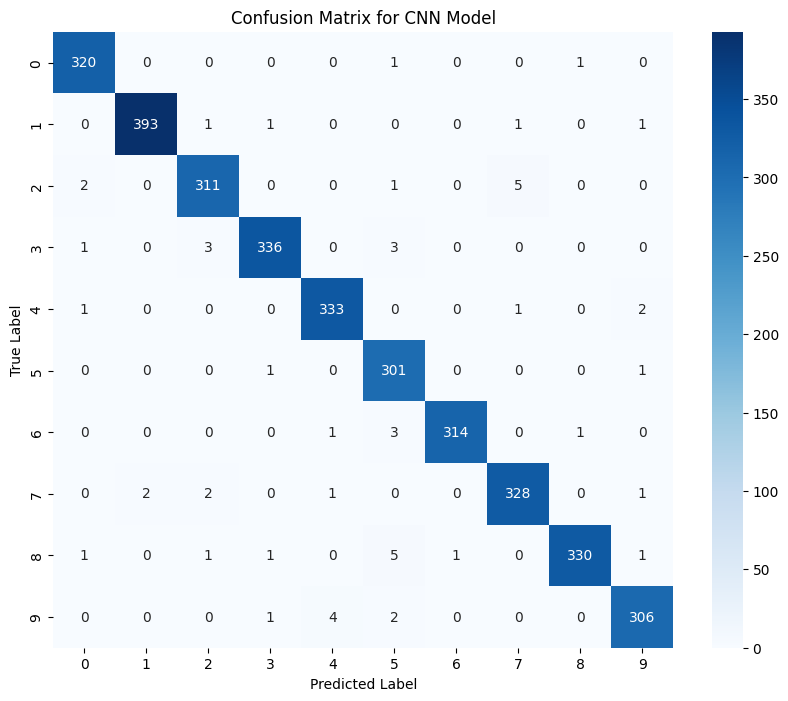

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions with the CNN model on the test data
y_pred_cnn_probs = cnn.predict(X_test)
y_pred_cnn = np.argmax(y_pred_cnn_probs, axis=1)

# Generate the confusion matrix
cm_cnn = confusion_matrix(y_test, y_pred_cnn)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for CNN Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

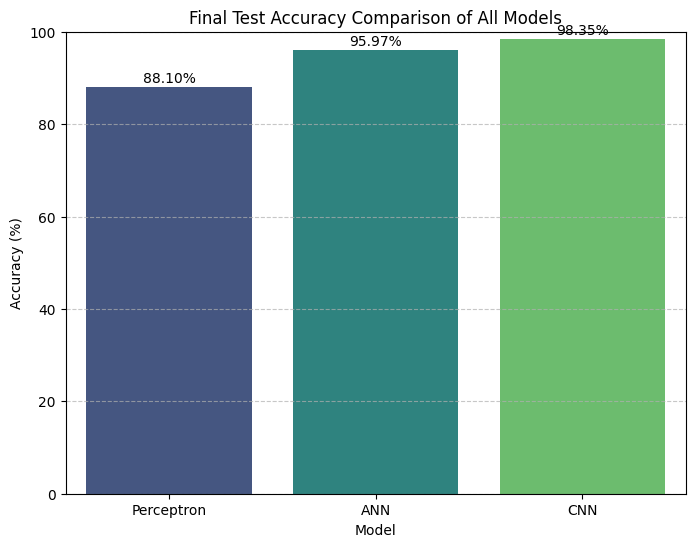

In [53]:
model_names = ['Perceptron', 'ANN', 'CNN']
final_accuracies = [Perceptron.evaluate(X_test_img, y_test_cat, verbose=0)[1],
                    ann.evaluate(X_test_img, y_test_cat, verbose=0)[1],
                    cnn.evaluate(X_test, y_test_cat, verbose=0)[1]]

plt.figure(figsize=(8, 6))
sns.barplot(x=model_names, y=np.array(final_accuracies) * 100, palette='viridis')
plt.title('Final Test Accuracy Comparison of All Models')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)

# Add accuracy values on top of the bars
for index, value in enumerate(np.array(final_accuracies) * 100):
    plt.text(index, value + 1, f'{value:.2f}%', ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()